In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\0afra\OneDrive\Desktop\prosper_credit_analysis\raw\prosperLoanData.csv")

In [2]:
df.shape

(113937, 81)

In [3]:
df.head(5)

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

In [5]:
df.columns.tolist()

['ListingKey',
 'ListingNumber',
 'ListingCreationDate',
 'CreditGrade',
 'Term',
 'LoanStatus',
 'ClosedDate',
 'BorrowerAPR',
 'BorrowerRate',
 'LenderYield',
 'EstimatedEffectiveYield',
 'EstimatedLoss',
 'EstimatedReturn',
 'ProsperRating (numeric)',
 'ProsperRating (Alpha)',
 'ProsperScore',
 'ListingCategory (numeric)',
 'BorrowerState',
 'Occupation',
 'EmploymentStatus',
 'EmploymentStatusDuration',
 'IsBorrowerHomeowner',
 'CurrentlyInGroup',
 'GroupKey',
 'DateCreditPulled',
 'CreditScoreRangeLower',
 'CreditScoreRangeUpper',
 'FirstRecordedCreditLine',
 'CurrentCreditLines',
 'OpenCreditLines',
 'TotalCreditLinespast7years',
 'OpenRevolvingAccounts',
 'OpenRevolvingMonthlyPayment',
 'InquiriesLast6Months',
 'TotalInquiries',
 'CurrentDelinquencies',
 'AmountDelinquent',
 'DelinquenciesLast7Years',
 'PublicRecordsLast10Years',
 'PublicRecordsLast12Months',
 'RevolvingCreditBalance',
 'BankcardUtilization',
 'AvailableBankcardCredit',
 'TotalTrades',
 'TradesNeverDelinquent (p

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ListingKey,113937,113066,17A93590655669644DB4C06,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ListingNumber,113937.0,NaN,NaN,NaN,627885.692506,328076.236386,4.0,400919.0,600554.0,892634.0,1255725.0
ListingCreationDate,113937,113064,2013-10-02 17:20:16.550000000,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditGrade,28953,8,C,5649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Term,113937.0,NaN,NaN,NaN,40.830248,10.436212,12.0,36.0,36.0,36.0,60.0
...,...,...,...,...,...,...,...,...,...,...,...
PercentFunded,113937.0,NaN,NaN,NaN,0.998584,0.017919,0.7,1.0,1.0,1.0,1.0125
Recommendations,113937.0,NaN,NaN,NaN,0.048027,0.332353,0.0,0.0,0.0,0.0,39.0
InvestmentFromFriendsCount,113937.0,NaN,NaN,NaN,0.02346,0.232412,0.0,0.0,0.0,0.0,33.0
InvestmentFromFriendsAmount,113937.0,NaN,NaN,NaN,16.550751,294.545422,0.0,0.0,0.0,0.0,25000.0


In [7]:
df.isnull().sum().sort_values(ascending=False)

GroupKey                         100596
LoanFirstDefaultedCycleNumber     96985
ScorexChangeAtTimeOfListing       95009
ProsperPrincipalOutstanding       91852
ProsperPrincipalBorrowed          91852
                                  ...  
IncomeRange                           0
IncomeVerifiable                      0
StatedMonthlyIncome                   0
LoanKey                               0
Investors                             0
Length: 81, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['LoanStatus'].value_counts(dropna=False)


LoanStatus
Current                   56576
Completed                 38074
Chargedoff                11992
Defaulted                  5018
Past Due (1-15 days)        806
Past Due (31-60 days)       363
Past Due (61-90 days)       313
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      205
Past Due (>120 days)         16
Cancelled                     5
Name: count, dtype: int64

In [10]:
audit_df = pd.DataFrame({
    "Column": df.columns
})
audit_df.head()


,Column
0,ListingKey
1,ListingNumber
2,ListingCreationDate
3,CreditGrade
4,Term


In [11]:
audit_df["Business Category"] = pd.NA
audit_df["Keep?"] = pd.NA
audit_df["Reason"] = pd.NA
audit_df["Available Before Loan?"] = pd.NA


In [12]:
audit_df.shape


(81, 5)

In [13]:
df_clean = df.copy()

In [14]:
df_clean.duplicated().sum()

np.int64(0)

In [15]:
analysis_df = df_clean.copy()

In [16]:
missing = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

GroupKey                         100596
LoanFirstDefaultedCycleNumber     96985
ScorexChangeAtTimeOfListing       95009
ProsperPrincipalOutstanding       91852
ProsperPrincipalBorrowed          91852
                                  ...  
IncomeRange                           0
IncomeVerifiable                      0
StatedMonthlyIncome                   0
LoanKey                               0
Investors                             0
Length: 81, dtype: int64

In [17]:
missing_percentage = (
    df_clean.isnull().mean()*100
).sort_values(ascending=False)

missing_percentage

GroupKey                         88.290898
LoanFirstDefaultedCycleNumber    85.121602
ScorexChangeAtTimeOfListing      83.387311
ProsperPrincipalOutstanding      80.616481
ProsperPrincipalBorrowed         80.616481
                                   ...    
IncomeRange                       0.000000
IncomeVerifiable                  0.000000
StatedMonthlyIncome               0.000000
LoanKey                           0.000000
Investors                         0.000000
Length: 81, dtype: float64

In [18]:
missing_df = pd.DataFrame({

"Missing Values":missing,

"Percentage":missing_percentage

})

missing_df.head(10)

,Missing Values,Percentage
GroupKey,100596,88.290898
LoanFirstDefaultedCycleNumber,96985,85.121602
ScorexChangeAtTimeOfListing,95009,83.387311
ProsperPrincipalOutstanding,91852,80.616481
ProsperPrincipalBorrowed,91852,80.616481
ProsperPaymentsOneMonthPlusLate,91852,80.616481
ProsperPaymentsLessThanOneMonthLate,91852,80.616481
OnTimeProsperPayments,91852,80.616481
TotalProsperLoans,91852,80.616481
TotalProsperPaymentsBilled,91852,80.616481


In [19]:
columns_to_drop=[]

In [20]:
date_columns = [
    "ListingCreationDate",
    "ClosedDate",         
    "DateCreditPulled",
    "FirstRecordedCreditLine",
    "LoanOriginationDate"
]

df[date_columns] = df[date_columns].apply(pd.to_datetime, errors="coerce")

In [21]:
print(df.columns.tolist())

['ListingKey', 'ListingNumber', 'ListingCreationDate', 'CreditGrade', 'Term', 'LoanStatus', 'ClosedDate', 'BorrowerAPR', 'BorrowerRate', 'LenderYield', 'EstimatedEffectiveYield', 'EstimatedLoss', 'EstimatedReturn', 'ProsperRating (numeric)', 'ProsperRating (Alpha)', 'ProsperScore', 'ListingCategory (numeric)', 'BorrowerState', 'Occupation', 'EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner', 'CurrentlyInGroup', 'GroupKey', 'DateCreditPulled', 'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'FirstRecordedCreditLine', 'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingAccounts', 'OpenRevolvingMonthlyPayment', 'InquiriesLast6Months', 'TotalInquiries', 'CurrentDelinquencies', 'AmountDelinquent', 'DelinquenciesLast7Years', 'PublicRecordsLast10Years', 'PublicRecordsLast12Months', 'RevolvingCreditBalance', 'BankcardUtilization', 'AvailableBankcardCredit', 'TotalTrades', 'TradesNeverDelinquent (percentage)', 'TradesOpenedLast6Months', 'Deb

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

In [23]:
missing_df.head(30)

,Missing Values,Percentage
GroupKey,100596,88.290898
LoanFirstDefaultedCycleNumber,96985,85.121602
ScorexChangeAtTimeOfListing,95009,83.387311
ProsperPrincipalOutstanding,91852,80.616481
ProsperPrincipalBorrowed,91852,80.616481
ProsperPaymentsOneMonthPlusLate,91852,80.616481
ProsperPaymentsLessThanOneMonthLate,91852,80.616481
OnTimeProsperPayments,91852,80.616481
TotalProsperLoans,91852,80.616481
TotalProsperPaymentsBilled,91852,80.616481


In [24]:

date_columns = [
    "ListingCreationDate",
    "ClosedDate",
    "DateCreditPulled",
    "FirstRecordedCreditLine",
    "LoanOriginationDate"
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(
        df_clean[col],
        format="mixed",
        errors="coerce"
    )

In [25]:
missing_df["Decision"] = ""
missing_df.head(30)

,Missing Values,Percentage,Decision
GroupKey,100596,88.290898,
LoanFirstDefaultedCycleNumber,96985,85.121602,
ScorexChangeAtTimeOfListing,95009,83.387311,
ProsperPrincipalOutstanding,91852,80.616481,
ProsperPrincipalBorrowed,91852,80.616481,
ProsperPaymentsOneMonthPlusLate,91852,80.616481,
ProsperPaymentsLessThanOneMonthLate,91852,80.616481,
OnTimeProsperPayments,91852,80.616481,
TotalProsperLoans,91852,80.616481,
TotalProsperPaymentsBilled,91852,80.616481,


In [26]:
pd.crosstab(
    df_clean["CreditGrade"].isna(),
    df_clean["ProsperRating (Alpha)"].isna()
)

ProsperRating (Alpha),False,True
CreditGrade,,
False,0,28953
True,84853,131


In [27]:
df_clean["LoanStatus"].value_counts()

LoanStatus
Current                   56576
Completed                 38074
Chargedoff                11992
Defaulted                  5018
Past Due (1-15 days)        806
Past Due (31-60 days)       363
Past Due (61-90 days)       313
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      205
Past Due (>120 days)         16
Cancelled                     5
Name: count, dtype: int64

In [28]:
missing_df.loc["GroupKey", "Decision"] = "Drop"

missing_df.loc["LoanFirstDefaultedCycleNumber", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["ScorexChangeAtTimeOfListing", "Decision"] = "Drop"

missing_df.loc["ProsperPrincipalOutstanding", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["ProsperPrincipalBorrowed", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["ProsperPaymentsOneMonthPlusLate", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["ProsperPaymentsLessThanOneMonthLate", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["OnTimeProsperPayments", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["TotalProsperLoans", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["TotalProsperPaymentsBilled", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["CreditGrade", "Decision"] = "Investigate"

missing_df.loc["ClosedDate", "Decision"] = "Keep (Leave NaN)"

missing_df.loc["ProsperRating (Alpha)", "Decision"] = "Investigate"

missing_df.loc["ProsperScore", "Decision"] = "Investigate"

missing_df.loc["EstimatedReturn", "Decision"] = "Investigate"

missing_df.loc["ProsperRating (numeric)", "Decision"] = "Investigate"

missing_df.loc["EstimatedLoss", "Decision"] = "Investigate"

missing_df.loc["EstimatedEffectiveYield", "Decision"] = "Investigate"

In [29]:
missing_df.head(20)

,Missing Values,Percentage,Decision
GroupKey,100596,88.290898,Drop
LoanFirstDefaultedCycleNumber,96985,85.121602,Keep (Leave NaN)
ScorexChangeAtTimeOfListing,95009,83.387311,Drop
ProsperPrincipalOutstanding,91852,80.616481,Keep (Leave NaN)
ProsperPrincipalBorrowed,91852,80.616481,Keep (Leave NaN)
ProsperPaymentsOneMonthPlusLate,91852,80.616481,Keep (Leave NaN)
ProsperPaymentsLessThanOneMonthLate,91852,80.616481,Keep (Leave NaN)
OnTimeProsperPayments,91852,80.616481,Keep (Leave NaN)
TotalProsperLoans,91852,80.616481,Keep (Leave NaN)
TotalProsperPaymentsBilled,91852,80.616481,Keep (Leave NaN)


In [30]:
df_final = df_clean[
    df_clean["LoanStatus"].isin([
        "Completed",
        "Chargedoff",
        "Defaulted"
    ])
]

In [31]:
date_columns = [
    "ListingCreationDate",
    "ClosedDate",
    "DateCreditPulled",
    "FirstRecordedCreditLine",
    "LoanOriginationDate"
]


df_clean[date_columns].describe()

,ListingCreationDate,ClosedDate,DateCreditPulled,FirstRecordedCreditLine,LoanOriginationDate
count,113937,55089,113937,113240,113937
mean,2011-07-09 08:07:23.491206656,2011-03-07 20:21:21.316172800,2011-07-09 15:28:40.444773888,1994-11-17 07:00:07.375485696,2011-07-21 03:18:19.460228096
min,2005-11-09 20:44:28.847000,2005-11-25 00:00:00,2005-11-09 00:30:04.487000,1947-08-24 00:00:00,2005-11-15 00:00:00
25%,2008-09-19 10:02:14.769999872,2009-07-14 00:00:00,2008-09-16 22:25:27.952999936,1990-06-01 00:00:00,2008-10-02 00:00:00
50%,2012-06-16 12:37:19.990000128,2011-04-05 00:00:00,2012-06-17 07:52:34,1995-11-01 00:00:00,2012-06-26 00:00:00
75%,2013-09-09 19:40:48.963000064,2013-01-30 00:00:00,2013-09-11 14:30:24,2000-03-14 00:00:00,2013-09-18 00:00:00
max,2014-03-10 12:20:53.760000,2014-03-10 00:00:00,2014-03-10 12:20:56,2012-12-22 00:00:00,2014-03-12 00:00:00


In [32]:
print(pd.__version__)

2.3.3


In [33]:
columns_to_drop = [
    "GroupKey",
    "ListingNumber",
    "LoanNumber"
]

In [34]:
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(df_clean[col].value_counts(dropna=False).head(10))


ListingKey
ListingKey
17A93590655669644DB4C06    6
349D3587495831350F0F648    4
DE8535960513435199406CE    4
8474358854651984137201C    4
47C1359638497431975670B    4
85B8359189827433103090E    3
A2753594947212496DDDAB1    3
78D835971025680406A3489    3
F0423591427069869236786    3
26C835968174004476E551B    3
Name: count, dtype: int64

CreditGrade
CreditGrade
NaN    84984
C       5649
D       5153
B       4389
AA      3509
HR      3508
A       3315
E       3289
NC       141
Name: count, dtype: int64

LoanStatus
LoanStatus
Current                   56576
Completed                 38074
Chargedoff                11992
Defaulted                  5018
Past Due (1-15 days)        806
Past Due (31-60 days)       363
Past Due (61-90 days)       313
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      205
Name: count, dtype: int64

ProsperRating (Alpha)
ProsperRating (Alpha)
NaN    29084
C      18345
B      15581
A      14551
D      14274
E       9795
H

In [35]:
numeric_summary = df_clean.describe().T

numeric_summary

,count,mean,min,25%,50%,75%,max,std
ListingNumber,113937.0,627885.692506,4.0,400919.0,600554.0,892634.0,1255725.0,328076.236386
ListingCreationDate,113937,2011-07-09 08:07:23.491206656,2005-11-09 20:44:28.847000,2008-09-19 10:02:14.769999872,2012-06-16 12:37:19.990000128,2013-09-09 19:40:48.963000064,2014-03-10 12:20:53.760000,NaN
Term,113937.0,40.830248,12.0,36.0,36.0,36.0,60.0,10.436212
ClosedDate,55089,2011-03-07 20:21:21.316172800,2005-11-25 00:00:00,2009-07-14 00:00:00,2011-04-05 00:00:00,2013-01-30 00:00:00,2014-03-10 00:00:00,NaN
BorrowerAPR,113912.0,0.218828,0.00653,0.15629,0.20976,0.28381,0.51229,0.080364
...,...,...,...,...,...,...,...,...
PercentFunded,113937.0,0.998584,0.7,1.0,1.0,1.0,1.0125,0.017919
Recommendations,113937.0,0.048027,0.0,0.0,0.0,0.0,39.0,0.332353
InvestmentFromFriendsCount,113937.0,0.02346,0.0,0.0,0.0,0.0,33.0,0.232412
InvestmentFromFriendsAmount,113937.0,16.550751,0.0,0.0,0.0,0.0,25000.0,294.545422


In [36]:
important_numeric = [
    "LoanOriginalAmount",
    "BorrowerAPR",
    "BorrowerRate",
    "DebtToIncomeRatio",
    "StatedMonthlyIncome",
    "MonthlyLoanPayment"
]

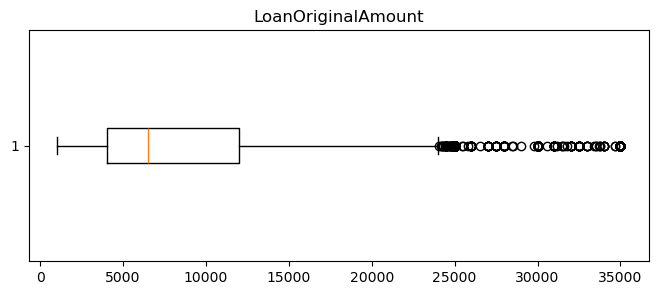

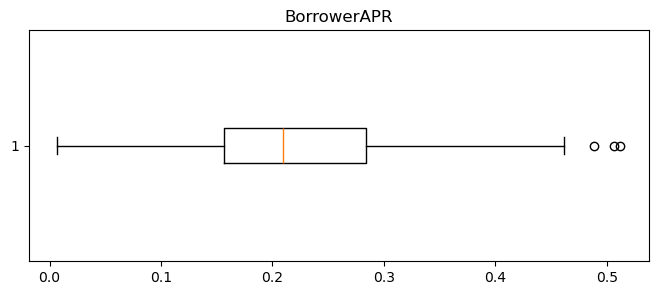

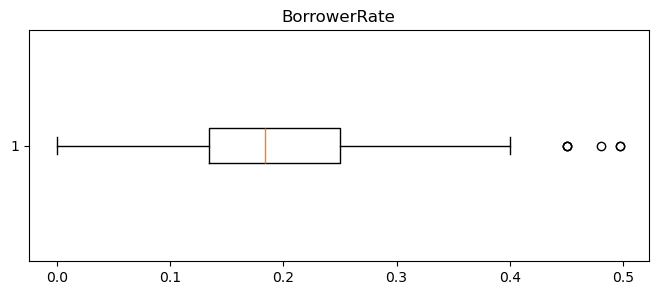

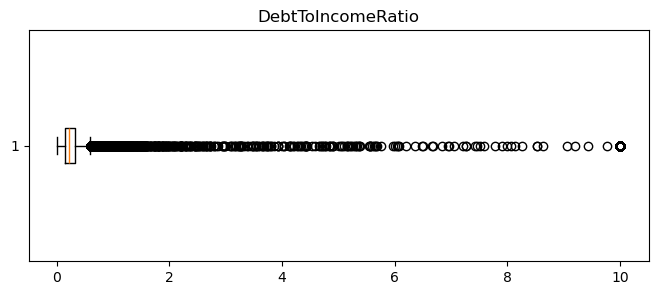

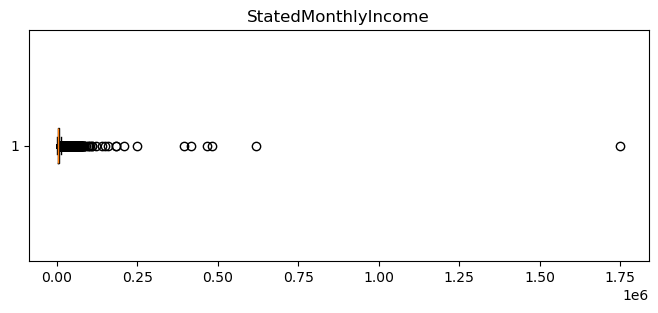

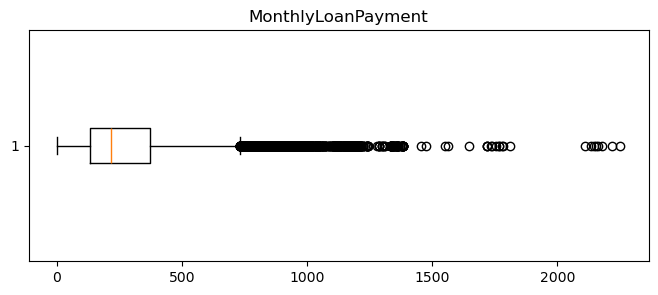

In [37]:


for col in important_numeric:
    plt.figure(figsize=(8,3))
    plt.boxplot(df_clean[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [38]:
df_clean["StatedMonthlyIncome"].nlargest(10)

53167     1.750003e+06
53014     6.185478e+05
17411     4.833333e+05
57133     4.666667e+05
8066      4.166667e+05
113270    3.944000e+05
82831     2.500000e+05
8870      2.083333e+05
56867     1.850818e+05
83697     1.850818e+05
Name: StatedMonthlyIncome, dtype: float64

In [39]:
df_clean["DebtToIncomeRatio"].describe()


count    105383.000000
mean          0.275947
std           0.551759
min           0.000000
25%           0.140000
50%           0.220000
75%           0.320000
max          10.010000
Name: DebtToIncomeRatio, dtype: float64

In [40]:
df_clean["DebtToIncomeRatio"].nlargest(10)

226     10.01
576     10.01
626     10.01
1242    10.01
1925    10.01
2155    10.01
2217    10.01
2394    10.01
2715    10.01
3494    10.01
Name: DebtToIncomeRatio, dtype: float64

In [41]:
#feature engineering

In [42]:
analysis_df = df_clean.copy()

In [43]:
analysis_df["AverageCreditScore"] = (
    analysis_df["CreditScoreRangeLower"] +
    analysis_df["CreditScoreRangeUpper"]
) / 2

In [44]:
analysis_df["PaymentBurdenRatio"] = (
    analysis_df["MonthlyLoanPayment"] /
    analysis_df["StatedMonthlyIncome"]
)

In [45]:
df_clean["LoanStatus"].value_counts(dropna=False)

LoanStatus
Current                   56576
Completed                 38074
Chargedoff                11992
Defaulted                  5018
Past Due (1-15 days)        806
Past Due (31-60 days)       363
Past Due (61-90 days)       313
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      205
Past Due (>120 days)         16
Cancelled                     5
Name: count, dtype: int64

In [46]:
loan_outcome_map = {
    "Completed": "Good",

    "Chargedoff": "Bad",
    "Defaulted": "Bad",

    "Current": "Ongoing",
    "FinalPaymentInProgress": "Ongoing",

    "Past Due (1-15 days)": "Ongoing",
    "Past Due (16-30 days)": "Ongoing",
    "Past Due (31-60 days)": "Ongoing",
    "Past Due (61-90 days)": "Ongoing",
    "Past Due (91-120 days)": "Ongoing",
    "Past Due (>120 days)": "Ongoing",

    "Cancelled": "Cancelled"
}

In [47]:
df_clean["LoanOutcome"] = df_clean["LoanStatus"].map(loan_outcome_map)

In [48]:
df_clean["LoanOutcome"].value_counts()

LoanOutcome
Ongoing      58848
Good         38074
Bad          17010
Cancelled        5
Name: count, dtype: int64

In [49]:
analysis_df

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,AverageCreditScore,PaymentBurdenRatio
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263,C,36,Completed,2009-08-14,0.16516,0.1580,0.1380,...,0.0,0.0,0.0,1.0,0,0,0.0,258,649.5,0.107166
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900,NaN,36,Current,NaT,0.12016,0.0920,0.0820,...,0.0,0.0,0.0,1.0,0,0,0.0,1,689.5,0.052070
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090,HR,36,Completed,2009-12-17,0.28269,0.2750,0.2400,...,0.0,0.0,0.0,1.0,0,0,0.0,41,489.5,0.059194
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010,NaN,36,Current,NaT,0.12528,0.0974,0.0874,...,0.0,0.0,0.0,1.0,0,0,0.0,158,809.5,0.111809
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097,NaN,36,Current,NaT,0.24614,0.2085,0.1985,...,0.0,0.0,0.0,1.0,0,0,0.0,20,689.5,0.058849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113932,E6D9357655724827169606C,753087,2013-04-14 05:55:02.663,NaN,36,Current,NaT,0.22354,0.1864,0.1764,...,0.0,0.0,0.0,1.0,0,0,0.0,1,709.5,0.084171
113933,E6DB353036033497292EE43,537216,2011-11-03 20:42:55.333,NaN,36,FinalPaymentInProgress,NaT,0.13220,0.1110,0.1010,...,0.0,0.0,0.0,1.0,0,0,0.0,22,709.5,0.008154
113934,E6E13596170052029692BB1,1069178,2013-12-13 05:49:12.703,NaN,60,Current,NaT,0.23984,0.2150,0.2050,...,0.0,0.0,0.0,1.0,0,0,0.0,119,709.5,0.095078
113935,E6EB3531504622671970D9E,539056,2011-11-14 13:18:26.597,NaN,60,Completed,2013-08-13,0.28408,0.2605,0.2505,...,0.0,0.0,0.0,1.0,0,0,0.0,274,689.5,0.116013


In [50]:
df_clean[df_clean["LoanOutcome"].isna()]["LoanStatus"].unique()  #all values are mapped

array([], dtype=object)

In [51]:
print(df_clean[["LoanOriginationDate", "FirstRecordedCreditLine"]].dtypes)
print(analysis_df[["LoanOriginationDate", "FirstRecordedCreditLine"]].dtypes)

LoanOriginationDate        datetime64[ns]
FirstRecordedCreditLine    datetime64[ns]
dtype: object
LoanOriginationDate        datetime64[ns]
FirstRecordedCreditLine    datetime64[ns]
dtype: object


In [52]:
date_columns = [
    "ListingCreationDate",
    "ClosedDate",
    "DateCreditPulled",
    "FirstRecordedCreditLine",
    "LoanOriginationDate"
]

for col in date_columns:
    analysis_df[col] = pd.to_datetime(
        analysis_df[col],
        format="mixed",
        errors="coerce"
    )

In [53]:
analysis_df["CreditHistoryYears"] = (
    (df_clean["LoanOriginationDate"] - df_clean["FirstRecordedCreditLine"])
    .dt.days / 365.25
)

analysis_df["CreditHistoryYears"].describe()

count    113240.000000
mean         16.705173
std           7.965807
min           0.052019
25%          11.271732
50%          15.663244
75%          21.174538
max          63.041752
Name: CreditHistoryYears, dtype: float64

In [54]:
analysis_df[["LoanOriginationDate", "FirstRecordedCreditLine"]].dtypes

LoanOriginationDate        datetime64[ns]
FirstRecordedCreditLine    datetime64[ns]
dtype: object

In [55]:
analysis_df[
    [
        "AverageCreditScore",
        "PaymentBurdenRatio",
        "LoanOutcome",
        "CreditHistoryYears"
    ]
].head()

KeyError: "['LoanOutcome'] not in index"

In [ ]:
analysis_df[
    [
        "AverageCreditScore",
        "PaymentBurdenRatio",
        "LoanOutcome",
        "CreditHistoryYears"
    ]
].describe()

In [ ]:
#investigating our findings

In [ ]:
analysis_df.loc[
    analysis_df["AverageCreditScore"] < 300,
    [
        "CreditScoreRangeLower",
        "CreditScoreRangeUpper",
        "AverageCreditScore",
        "LoanStatus"
    ]
].head(20)     #missing credit scores

In [ ]:
analysis_df["PaymentBurdenRatio"] = (
    analysis_df["MonthlyLoanPayment"] /
    analysis_df["StatedMonthlyIncome"].replace(0, np.nan)
)

In [ ]:
analysis_df["PaymentBurdenRatio"].describe()

In [ ]:
analysis_df["LoanOutcome"].value_counts()

In [ ]:
mask = analysis_df["AverageCreditScore"] < 300

analysis_df.loc[mask, [
    "CreditScoreRangeLower",
    "CreditScoreRangeUpper",
    "AverageCreditScore"
]] = np.nan

In [ ]:
analysis_df["AverageCreditScore"].describe()

In [ ]:
analysis_df.nlargest(
    10,
    "PaymentBurdenRatio"
)[[
    "MonthlyLoanPayment",
    "StatedMonthlyIncome",
    "PaymentBurdenRatio",
    "LoanStatus",
    "LoanOriginalAmount"
]]

In [ ]:
completed_df = analysis_df[
    analysis_df["LoanOutcome"].isin(["Good", "Bad"])
]

In [ ]:
completed_df.describe()

In [ ]:
columns_to_drop = [
    "GroupKey",
    "ListingNumber",
    "LoanNumber"
]

analysis_df = analysis_df.drop(columns=columns_to_drop)

In [ ]:
analysis_df.loc[
    analysis_df["AverageCreditScore"] < 300,
    "AverageCreditScore"
] = np.nan   ##fixing credit score

In [ ]:
analysis_df.loc[
    analysis_df["StatedMonthlyIncome"] <= 1,
    "StatedMonthlyIncome"
] = np.nan

analysis_df["PaymentBurdenRatio"] = (
    analysis_df["MonthlyLoanPayment"] /
    analysis_df["StatedMonthlyIncome"]
)

In [ ]:
analysis_df["PaymentBurdenRatio"].describe()

In [56]:
previous_loan_cols = [
    "TotalProsperLoans",
    "TotalProsperPaymentsBilled",
    "OnTimeProsperPayments",
    "ProsperPaymentsLessThanOneMonthLate",
    "ProsperPaymentsOneMonthPlusLate",
    "ProsperPrincipalBorrowed",
    "ProsperPrincipalOutstanding"
]

analysis_df[previous_loan_cols] = (
    analysis_df[previous_loan_cols]
    .fillna(0)
)        ## represents previous loans

In [57]:
missing = (
    analysis_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

GroupKey                              100596
LoanFirstDefaultedCycleNumber          96985
ScorexChangeAtTimeOfListing            95009
CreditGrade                            84984
ClosedDate                             58848
ProsperScore                           29084
ProsperRating (numeric)                29084
ProsperRating (Alpha)                  29084
EstimatedEffectiveYield                29084
EstimatedLoss                          29084
EstimatedReturn                        29084
DebtToIncomeRatio                       8554
EmploymentStatusDuration                7625
AmountDelinquent                        7622
CurrentCreditLines                      7604
OpenCreditLines                         7604
BankcardUtilization                     7604
PublicRecordsLast12Months               7604
RevolvingCreditBalance                  7604
AvailableBankcardCredit                 7544
TotalTrades                             7544
TradesNeverDelinquent (percentage)      7544
TradesOpen

In [58]:
analysis_df[
    [
        "TotalProsperLoans",
        "ProsperPrincipalBorrowed",
        "LoanStatus"
    ]
].sample(10, random_state=42)

,TotalProsperLoans,ProsperPrincipalBorrowed,LoanStatus
15343,1.0,3000.0,Chargedoff
55980,0.0,0.0,Completed
46941,0.0,0.0,Current
42395,0.0,0.0,Completed
58127,0.0,0.0,Chargedoff
78124,0.0,0.0,Completed
23445,1.0,12500.0,Completed
41926,0.0,0.0,Completed
106838,0.0,0.0,Completed
21240,0.0,0.0,Current


In [59]:
analysis_df["TotalProsperLoans"].value_counts(dropna=False).head(10)

TotalProsperLoans
0.0    91853
1.0    15538
2.0     4540
3.0     1447
4.0      417
5.0      104
6.0       29
7.0        8
8.0        1
Name: count, dtype: int64

In [60]:
analysis_df.duplicated().sum()

np.int64(0)

In [61]:
analysis_df.shape

(113937, 84)

In [62]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 84 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   ListingKey                           113937 non-null  object        
 1   ListingNumber                        113937 non-null  int64         
 2   ListingCreationDate                  113937 non-null  datetime64[ns]
 3   CreditGrade                          28953 non-null   object        
 4   Term                                 113937 non-null  int64         
 5   LoanStatus                           113937 non-null  object        
 6   ClosedDate                           55089 non-null   datetime64[ns]
 7   BorrowerAPR                          113912 non-null  float64       
 8   BorrowerRate                         113937 non-null  float64       
 9   LenderYield                          113937 non-null  float64       
 

In [63]:
analysis_df.loc[
    analysis_df["StatedMonthlyIncome"] <= 1,
    "StatedMonthlyIncome"
].value_counts()

StatedMonthlyIncome
0.000000    1394
0.083333     251
0.833333       1
0.250000       1
Name: count, dtype: int64

In [64]:
analysis_df.loc[
    np.isinf(analysis_df["PaymentBurdenRatio"]),
    ["MonthlyLoanPayment", "StatedMonthlyIncome", "PaymentBurdenRatio"]
].head(20)

,MonthlyLoanPayment,StatedMonthlyIncome,PaymentBurdenRatio
78,171.13,0.0,inf
100,172.76,0.0,inf
108,564.07,0.0,inf
125,217.74,0.0,inf
170,397.55,0.0,inf
186,173.71,0.0,inf
332,39.10,0.0,inf
335,86.85,0.0,inf
688,102.05,0.0,inf
772,112.61,0.0,inf


In [65]:
analysis_df.to_csv(
    r"C:\Users\0afra\OneDrive\Desktop\prosper_credit_analysis\processed\prosper_analysis_ready.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: 'C:\Users\0afra\OneDrive\Desktop\prosper_credit_analysis\processed'

In [ ]:
median_cols = [
    "DebtToIncomeRatio",
    "EmploymentStatusDuration",
    "AmountDelinquent",
    "OpenCreditLines",
    "CurrentCreditLines",
    "BankcardUtilization",
    "RevolvingCreditBalance",
    "TradesNeverDelinquent (percentage)",
    "TradesOpenedLast6Months",
    "AvailableBankcardCredit",
    "TotalTrades",
    "TotalInquiries",
    "DelinquenciesLast7Years",
    "CreditScoreRangeLower",
    "CreditScoreRangeUpper",
    "PublicRecordsLast10Years",
    "CurrentDelinquencies",
    "InquiriesLast6Months",
    "TotalCreditLinespast7years"
]

for col in median_cols:
    analysis_df[col] = analysis_df[col].fillna(
        analysis_df[col].median()
    )

In [ ]:
mode_cols = [
    "BorrowerState",
    "Occupation",
    "EmploymentStatus"
]

for col in mode_cols:
    analysis_df[col] = analysis_df[col].fillna(
        analysis_df[col].mode()[0]
    )

In [66]:
#fixing size of data 

In [67]:
df_clean.shape

(113937, 82)

In [68]:
df_clean["ListingKey"].nunique()

113066

In [69]:
df_clean["ListingKey"].duplicated().sum()

np.int64(871)

In [70]:
df_clean["ListingKey"].value_counts().value_counts().sort_index()

count
1    112239
2       790
3        32
4         4
6         1
Name: count, dtype: int64

In [71]:
print("ListingKey unique:", df_clean["ListingKey"].nunique())
print("LoanKey unique:", df_clean["LoanKey"].nunique())
print("LoanKey duplicates:", df_clean["LoanKey"].duplicated().sum())

ListingKey unique: 113066
LoanKey unique: 113066
LoanKey duplicates: 871


In [72]:
duplicate_keys = df_clean[
    df_clean["ListingKey"].duplicated(keep=False)
].sort_values("ListingKey")

duplicate_keys[
    [
        "ListingKey",
        "LoanKey",
        "ListingCreationDate",
        "LoanStatus",
        "LoanOriginalAmount",
        "LoanOriginationDate"
    ]
].head(30)

,ListingKey,LoanKey,ListingCreationDate,LoanStatus,LoanOriginalAmount,LoanOriginationDate
32680,00223594917038064A7C947,A352369967047316033A599,2013-11-15 16:58:37.167,Current,5000,2013-11-26
32681,00223594917038064A7C947,A352369967047316033A599,2013-11-15 16:58:37.167,Current,5000,2013-11-26
32964,00473590513960687DD308F,1C5336968140286844BD165,2013-10-07 15:47:36.023,Current,25000,2013-10-21
17274,00473590513960687DD308F,1C5336968140286844BD165,2013-10-07 15:47:36.023,Current,25000,2013-10-21
7478,0098360461900952056DB93,8FB43708171502806EBC521,2014-03-02 14:21:39.583,Current,4000,2014-03-07
33220,0098360461900952056DB93,8FB43708171502806EBC521,2014-03-02 14:21:39.583,Current,4000,2014-03-07
27677,01163604029146842E28D9C,6EE03706964847482C65EC7,2014-02-25 14:33:39.830,Current,10000,2014-02-27
788,01163604029146842E28D9C,6EE03706964847482C65EC7,2014-02-25 14:33:39.830,Current,10000,2014-02-27
27360,014F35910923350802E1B29,3EA23697860658303BB5CAB,2013-09-26 16:44:24.163,Current,8500,2013-10-31
18324,014F35910923350802E1B29,3EA23697860658303BB5CAB,2013-09-26 16:44:24.163,Current,8500,2013-10-31


In [73]:
duplicate_rows = df_clean[
    df_clean["ListingKey"].duplicated(keep=False)
]

duplicate_rows.duplicated().sum()

np.int64(0)

In [74]:
df_clean[df_clean["ListingKey"].duplicated(keep=False)].groupby(
    "ListingKey"
).size().value_counts()

2    790
3     32
4      4
6      1
Name: count, dtype: int64

In [75]:
duplicate_rows = df_clean[
    df_clean["ListingKey"].duplicated(keep=False)
]

diff_columns = []

for col in df_clean.columns:
    if duplicate_rows.groupby("ListingKey")[col].nunique(dropna=False).max() > 1:
        diff_columns.append(col)

diff_columns

['ProsperScore']

In [76]:
duplicate_rows[
    ["ListingKey"] + diff_columns
].sort_values("ListingKey").head(30)

,ListingKey,ProsperScore
32680,00223594917038064A7C947,5.0
32681,00223594917038064A7C947,6.0
32964,00473590513960687DD308F,4.0
17274,00473590513960687DD308F,6.0
7478,0098360461900952056DB93,2.0
33220,0098360461900952056DB93,4.0
27677,01163604029146842E28D9C,2.0
788,01163604029146842E28D9C,3.0
27360,014F35910923350802E1B29,4.0
18324,014F35910923350802E1B29,7.0


In [77]:
df_clean[
    df_clean["ListingKey"].duplicated(keep=False)
][
    ["ListingKey",
     "ListingCreationDate",
     "DateCreditPulled",
     "ProsperScore",
     "LoanStatus",
     "LoanOriginalAmount"]
].sort_values("ListingKey").head(30)

,ListingKey,ListingCreationDate,DateCreditPulled,ProsperScore,LoanStatus,LoanOriginalAmount
32680,00223594917038064A7C947,2013-11-15 16:58:37.167,2013-11-04 15:15:31,5.0,Current,5000
32681,00223594917038064A7C947,2013-11-15 16:58:37.167,2013-11-04 15:15:31,6.0,Current,5000
32964,00473590513960687DD308F,2013-10-07 15:47:36.023,2013-10-07 15:47:39,4.0,Current,25000
17274,00473590513960687DD308F,2013-10-07 15:47:36.023,2013-10-07 15:47:39,6.0,Current,25000
7478,0098360461900952056DB93,2014-03-02 14:21:39.583,2014-03-02 14:21:42,2.0,Current,4000
33220,0098360461900952056DB93,2014-03-02 14:21:39.583,2014-03-02 14:21:42,4.0,Current,4000
27677,01163604029146842E28D9C,2014-02-25 14:33:39.830,2014-02-23 18:05:46,2.0,Current,10000
788,01163604029146842E28D9C,2014-02-25 14:33:39.830,2014-02-23 18:05:46,3.0,Current,10000
27360,014F35910923350802E1B29,2013-09-26 16:44:24.163,2013-10-28 13:42:58,4.0,Current,8500
18324,014F35910923350802E1B29,2013-09-26 16:44:24.163,2013-10-28 13:42:58,7.0,Current,8500


In [78]:
df_clean[
    df_clean["ListingKey"].duplicated(keep=False)
].groupby("ListingKey")["ProsperScore"].agg(
    ["min", "max", "count"]
).describe()

,min,max,count
count,827.000000,827.000000,827.000000
mean,4.628779,6.605804,2.053204
std,2.424411,2.440451,0.273217
min,1.000000,2.000000,2.000000
25%,3.000000,4.000000,2.000000
50%,4.000000,7.000000,2.000000
75%,6.000000,8.000000,2.000000
max,10.000000,11.000000,6.000000


In [79]:
# Remove duplicate loans based on ListingKey
df_clean = df_clean.drop_duplicates(
    subset="ListingKey",
    keep="first"
).copy()

print("Shape after deduplication:", df_clean.shape)
print("Unique ListingKeys:", df_clean["ListingKey"].nunique())
print("Duplicate ListingKeys:", df_clean["ListingKey"].duplicated().sum())

Shape after deduplication: (113066, 82)
Unique ListingKeys: 113066
Duplicate ListingKeys: 0


In [80]:
print("Unique ListingKeys:", df_clean["ListingKey"].nunique())
print("Unique LoanKeys:", df_clean["LoanKey"].nunique())

print(
    "Duplicate ListingKeys:",
    df_clean["ListingKey"].duplicated().sum()
)

print(
    "Duplicate LoanKeys:",
    df_clean["LoanKey"].duplicated().sum()
)

Unique ListingKeys: 113066
Unique LoanKeys: 113066
Duplicate ListingKeys: 0
Duplicate LoanKeys: 0


In [81]:
print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum().sort_values(ascending=False).head(15))

print("\nUnique loans:")
print("ListingKey:", df_clean["ListingKey"].nunique())
print("LoanKey:", df_clean["LoanKey"].nunique())

Final dataset shape: (113066, 82)

Missing values:
GroupKey                               99727
LoanFirstDefaultedCycleNumber          96114
ScorexChangeAtTimeOfListing            94154
TotalProsperPaymentsBilled             91143
ProsperPaymentsOneMonthPlusLate        91143
ProsperPaymentsLessThanOneMonthLate    91143
ProsperPrincipalOutstanding            91143
ProsperPrincipalBorrowed               91143
TotalProsperLoans                      91143
OnTimeProsperPayments                  91143
CreditGrade                            84113
ClosedDate                             57990
EstimatedEffectiveYield                29084
EstimatedLoss                          29084
EstimatedReturn                        29084
dtype: int64

Unique loans:
ListingKey: 113066
LoanKey: 113066


In [82]:
#verification

In [83]:
df_clean["PaymentBurdenRatio"].describe()

KeyError: 'PaymentBurdenRatio'

In [ ]:
df_clean["PaymentBurdenRatio"].nlargest(10)

In [84]:
df_clean["DebtToIncomeRatio"].describe()

count    104594.000000
mean          0.276032
std           0.553738
min           0.000000
25%           0.140000
50%           0.220000
75%           0.320000
max          10.010000
Name: DebtToIncomeRatio, dtype: float64

In [85]:
df_clean["DebtToIncomeRatio"].nlargest(10)

226     10.01
576     10.01
626     10.01
1242    10.01
1925    10.01
2155    10.01
2217    10.01
2394    10.01
2715    10.01
3494    10.01
Name: DebtToIncomeRatio, dtype: float64

In [86]:


inf_counts = np.isinf(
    df_clean.select_dtypes(include="number")
).sum()

inf_counts = inf_counts[inf_counts > 0]

print(inf_counts)

Series([], dtype: int64)


In [87]:
final_df = df_clean.copy()

print(final_df.shape)

(113066, 82)


In [88]:
final_df.to_csv("prosper_final_clean.csv", index=False)

In [89]:
print("FINAL DATASET")
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))
print("Unique loans:", final_df["ListingKey"].nunique())

FINAL DATASET
Rows: 113066
Columns: 82
Unique loans: 113066


In [90]:
final_df.to_csv("prosper_final_clean.csv", index=False)

In [91]:
import os

print(os.path.abspath("prosper_final_clean.csv"))

C:\Users\0afra\prosper_final_clean.csv


In [92]:
#//////

In [93]:
df_clean.columns[df_clean.columns.duplicated()]

Index([], dtype='object')

In [94]:
df_clean.columns.tolist()

['ListingKey',
 'ListingNumber',
 'ListingCreationDate',
 'CreditGrade',
 'Term',
 'LoanStatus',
 'ClosedDate',
 'BorrowerAPR',
 'BorrowerRate',
 'LenderYield',
 'EstimatedEffectiveYield',
 'EstimatedLoss',
 'EstimatedReturn',
 'ProsperRating (numeric)',
 'ProsperRating (Alpha)',
 'ProsperScore',
 'ListingCategory (numeric)',
 'BorrowerState',
 'Occupation',
 'EmploymentStatus',
 'EmploymentStatusDuration',
 'IsBorrowerHomeowner',
 'CurrentlyInGroup',
 'GroupKey',
 'DateCreditPulled',
 'CreditScoreRangeLower',
 'CreditScoreRangeUpper',
 'FirstRecordedCreditLine',
 'CurrentCreditLines',
 'OpenCreditLines',
 'TotalCreditLinespast7years',
 'OpenRevolvingAccounts',
 'OpenRevolvingMonthlyPayment',
 'InquiriesLast6Months',
 'TotalInquiries',
 'CurrentDelinquencies',
 'AmountDelinquent',
 'DelinquenciesLast7Years',
 'PublicRecordsLast10Years',
 'PublicRecordsLast12Months',
 'RevolvingCreditBalance',
 'BankcardUtilization',
 'AvailableBankcardCredit',
 'TotalTrades',
 'TradesNeverDelinquent (p

In [95]:
df_clean.columns.value_counts().loc[lambda x: x > 1]

Series([], Name: count, dtype: int64)

In [96]:
df_clean.to_csv(
    r"C:\Users\0afra\OneDrive\Desktop\prosper_final.csv",
    index=False
)

print("Shape:", df_clean.shape)
print("Duplicate columns:", df_clean.columns.duplicated().sum())

Shape: (113066, 82)
Duplicate columns: 0


In [97]:
for i, col in enumerate(df_clean.columns, start=1):
    print(i, col)

1 ListingKey
2 ListingNumber
3 ListingCreationDate
4 CreditGrade
5 Term
6 LoanStatus
7 ClosedDate
8 BorrowerAPR
9 BorrowerRate
10 LenderYield
11 EstimatedEffectiveYield
12 EstimatedLoss
13 EstimatedReturn
14 ProsperRating (numeric)
15 ProsperRating (Alpha)
16 ProsperScore
17 ListingCategory (numeric)
18 BorrowerState
19 Occupation
20 EmploymentStatus
21 EmploymentStatusDuration
22 IsBorrowerHomeowner
23 CurrentlyInGroup
24 GroupKey
25 DateCreditPulled
26 CreditScoreRangeLower
27 CreditScoreRangeUpper
28 FirstRecordedCreditLine
29 CurrentCreditLines
30 OpenCreditLines
31 TotalCreditLinespast7years
32 OpenRevolvingAccounts
33 OpenRevolvingMonthlyPayment
34 InquiriesLast6Months
35 TotalInquiries
36 CurrentDelinquencies
37 AmountDelinquent
38 DelinquenciesLast7Years
39 PublicRecordsLast10Years
40 PublicRecordsLast12Months
41 RevolvingCreditBalance
42 BankcardUtilization
43 AvailableBankcardCredit
44 TotalTrades
45 TradesNeverDelinquent (percentage)
46 TradesOpenedLast6Months
47 DebtToIncom

In [98]:
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Unique ListingKeys:", df_clean["ListingKey"].nunique())
print("Unique LoanKeys:", df_clean["LoanKey"].nunique())
print("Duplicate columns:", df_clean.columns.duplicated().sum())

Rows: 113066
Columns: 82
Unique ListingKeys: 113066
Unique LoanKeys: 113066
Duplicate columns: 0


In [99]:
df_clean.dtypes

ListingKey                             object
ListingNumber                           int64
ListingCreationDate            datetime64[ns]
CreditGrade                            object
Term                                    int64
                                    ...      
Recommendations                         int64
InvestmentFromFriendsCount              int64
InvestmentFromFriendsAmount           float64
Investors                               int64
LoanOutcome                            object
Length: 82, dtype: object

In [100]:
print(df_clean.select_dtypes(include="int64").columns.tolist())

['ListingNumber', 'Term', 'ListingCategory (numeric)', 'OpenRevolvingAccounts', 'LoanCurrentDaysDelinquent', 'LoanMonthsSinceOrigination', 'LoanNumber', 'LoanOriginalAmount', 'Recommendations', 'InvestmentFromFriendsCount', 'Investors']


In [101]:
print(df_clean.select_dtypes(include="float64").columns.tolist())

['BorrowerAPR', 'BorrowerRate', 'LenderYield', 'EstimatedEffectiveYield', 'EstimatedLoss', 'EstimatedReturn', 'ProsperRating (numeric)', 'ProsperScore', 'EmploymentStatusDuration', 'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingMonthlyPayment', 'InquiriesLast6Months', 'TotalInquiries', 'CurrentDelinquencies', 'AmountDelinquent', 'DelinquenciesLast7Years', 'PublicRecordsLast10Years', 'PublicRecordsLast12Months', 'RevolvingCreditBalance', 'BankcardUtilization', 'AvailableBankcardCredit', 'TotalTrades', 'TradesNeverDelinquent (percentage)', 'TradesOpenedLast6Months', 'DebtToIncomeRatio', 'StatedMonthlyIncome', 'TotalProsperLoans', 'TotalProsperPaymentsBilled', 'OnTimeProsperPayments', 'ProsperPaymentsLessThanOneMonthLate', 'ProsperPaymentsOneMonthPlusLate', 'ProsperPrincipalBorrowed', 'ProsperPrincipalOutstanding', 'ScorexChangeAtTimeOfListing', 'LoanFirstDefaultedCycleNumber', 'MonthlyLoanPayment', 'L

In [102]:
print(df_clean.select_dtypes(include="datetime64[ns]").columns.tolist())

['ListingCreationDate', 'ClosedDate', 'DateCreditPulled', 'FirstRecordedCreditLine', 'LoanOriginationDate']


In [103]:
mysql_types = {}

for col, dtype in df_clean.dtypes.items():
    if str(dtype) == "int64":
        mysql_types[col] = "BIGINT"
    elif str(dtype) == "float64":
        mysql_types[col] = "DOUBLE"
    elif str(dtype) == "datetime64[ns]":
        mysql_types[col] = "DATETIME"
    else:
        mysql_types[col] = "TEXT"

create_sql = "CREATE TABLE prosper_loans (\n"

columns_sql = []

for col in df_clean.columns:
    columns_sql.append(
        f"    `{col.replace('`', '``')}` {mysql_types[col]}"
    )

create_sql += ",\n".join(columns_sql)
create_sql += "\n);"

print(create_sql)

CREATE TABLE prosper_loans (
    `ListingKey` TEXT,
    `ListingNumber` BIGINT,
    `ListingCreationDate` DATETIME,
    `CreditGrade` TEXT,
    `Term` BIGINT,
    `LoanStatus` TEXT,
    `ClosedDate` DATETIME,
    `BorrowerAPR` DOUBLE,
    `BorrowerRate` DOUBLE,
    `LenderYield` DOUBLE,
    `EstimatedEffectiveYield` DOUBLE,
    `EstimatedLoss` DOUBLE,
    `EstimatedReturn` DOUBLE,
    `ProsperRating (numeric)` DOUBLE,
    `ProsperRating (Alpha)` TEXT,
    `ProsperScore` DOUBLE,
    `ListingCategory (numeric)` BIGINT,
    `BorrowerState` TEXT,
    `Occupation` TEXT,
    `EmploymentStatus` TEXT,
    `EmploymentStatusDuration` DOUBLE,
    `IsBorrowerHomeowner` TEXT,
    `CurrentlyInGroup` TEXT,
    `GroupKey` TEXT,
    `DateCreditPulled` DATETIME,
    `CreditScoreRangeLower` DOUBLE,
    `CreditScoreRangeUpper` DOUBLE,
    `FirstRecordedCreditLine` DATETIME,
    `CurrentCreditLines` DOUBLE,
    `OpenCreditLines` DOUBLE,
    `TotalCreditLinespast7years` DOUBLE,
    `OpenRevolvingAccounts` B

In [105]:
!pip install mysql-connector-python

In [107]:
import mysql.connector

In [109]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=input("Enter your MySQL password: "),
    database="loandb"
)

cursor = conn.cursor()

print("Connected successfully!")

Enter your MySQL password:  Roronoazoro7


Connected successfully!


In [110]:
import pandas as pd
import numpy as np
from datetime import datetime

# Make sure we are working with the final cleaned dataset
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Rows: 113066
Columns: 82


In [111]:
def mysql_type(dtype):
    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "DATETIME"
    elif pd.api.types.is_integer_dtype(dtype):
        return "BIGINT"
    elif pd.api.types.is_float_dtype(dtype):
        return "DOUBLE"
    else:
        return "TEXT"


columns_sql = []

for col in df_clean.columns:
    sql_type = mysql_type(df_clean[col].dtype)
    safe_col = col.replace("`", "``")
    columns_sql.append(f"`{safe_col}` {sql_type} NULL")

create_sql = f"""
CREATE TABLE IF NOT EXISTS `prosper_loans_final` (
    {', '.join(columns_sql)}
)
"""

cursor.execute(create_sql)
conn.commit()

print("Table created successfully!")

Table created successfully!


In [112]:
cursor.execute("SHOW COLUMNS FROM `prosper_loans_final`")
result = cursor.fetchall()

print("MySQL columns:", len(result))

MySQL columns: 82


In [113]:
# Convert Pandas missing values to Python None
# MySQL Connector converts None to SQL NULL

upload_df = df_clean.astype(object).where(pd.notna(df_clean), None)

print("Rows ready:", len(upload_df))
print("Columns ready:", len(upload_df.columns))

Rows ready: 113066
Columns ready: 82


In [114]:
columns = ", ".join(
    f"`{col.replace('`', '``')}`"
    for col in upload_df.columns
)

placeholders = ", ".join(["%s"] * len(upload_df.columns))

insert_sql = f"""
INSERT INTO `prosper_loans_final`
({columns})
VALUES ({placeholders})
"""

In [115]:
first_row = tuple(upload_df.iloc[0])

cursor.execute(insert_sql, first_row)
conn.commit()

print("First row inserted successfully!")

First row inserted successfully!


In [116]:
import time

batch_size = 1000

start_time = time.time()

for start in range(1, len(upload_df), batch_size):
    batch = upload_df.iloc[start:start + batch_size]

    rows = [tuple(row) for row in batch.to_numpy()]

    cursor.executemany(insert_sql, rows)
    conn.commit()

    if start % 10000 == 1 or start + batch_size >= len(upload_df):
        print(f"Loaded {min(start + batch_size, len(upload_df)):,} / {len(upload_df):,}")

elapsed = time.time() - start_time

print(f"\nFinished loading dataset in {elapsed:.1f} seconds.")

Loaded 1,001 / 113,066
Loaded 11,001 / 113,066
Loaded 21,001 / 113,066
Loaded 31,001 / 113,066
Loaded 41,001 / 113,066
Loaded 51,001 / 113,066
Loaded 61,001 / 113,066
Loaded 71,001 / 113,066
Loaded 81,001 / 113,066
Loaded 91,001 / 113,066
Loaded 101,001 / 113,066
Loaded 111,001 / 113,066
Loaded 113,066 / 113,066

Finished loading dataset in 39.4 seconds.


In [117]:
cursor.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT ListingKey) AS unique_listings,
    COUNT(DISTINCT LoanKey) AS unique_loans
FROM prosper_loans_final
""")

result = cursor.fetchone()

print("Total rows:", result[0])
print("Unique ListingKeys:", result[1])
print("Unique LoanKeys:", result[2])

Total rows: 113066
Unique ListingKeys: 113066
Unique LoanKeys: 113066


In [118]:
cursor.execute("SHOW COLUMNS FROM prosper_loans_final")
columns = cursor.fetchall()

for col in columns:
    print(col[0])

ListingKey
ListingNumber
ListingCreationDate
CreditGrade
Term
LoanStatus
ClosedDate
BorrowerAPR
BorrowerRate
LenderYield
EstimatedEffectiveYield
EstimatedLoss
EstimatedReturn
ProsperRating (numeric)
ProsperRating (Alpha)
ProsperScore
ListingCategory (numeric)
BorrowerState
Occupation
EmploymentStatus
EmploymentStatusDuration
IsBorrowerHomeowner
CurrentlyInGroup
GroupKey
DateCreditPulled
CreditScoreRangeLower
CreditScoreRangeUpper
FirstRecordedCreditLine
CurrentCreditLines
OpenCreditLines
TotalCreditLinespast7years
OpenRevolvingAccounts
OpenRevolvingMonthlyPayment
InquiriesLast6Months
TotalInquiries
CurrentDelinquencies
AmountDelinquent
DelinquenciesLast7Years
PublicRecordsLast10Years
PublicRecordsLast12Months
RevolvingCreditBalance
BankcardUtilization
AvailableBankcardCredit
TotalTrades
TradesNeverDelinquent (percentage)
TradesOpenedLast6Months
DebtToIncomeRatio
IncomeRange
IncomeVerifiable
StatedMonthlyIncome
LoanKey
TotalProsperLoans
TotalProsperPaymentsBilled
OnTimeProsperPayments
P